In [7]:
import os
print(os.getcwd())

c:\Users\user 1\Desktop\climate-challenge-week0\notebooks


In [11]:
import os
print(os.listdir("data"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data'

In [12]:
import os
print(os.getcwd())

c:\Users\user 1\Desktop\climate-challenge-week0\notebooks


In [13]:
import pandas as pd

countries = ["ethiopia", "kenya", "tanzania", "nigeria", "sudan"]

dfs = []

for country in countries:
    df = pd.read_csv(f"../data/{country}.csv")  # ✅ FIXED PATH
    df["Country"] = country.capitalize()
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [14]:
import pandas as pd

data["DATE"] = pd.to_datetime(
    data["YEAR"] * 1000 + data["DOY"],
    format="%Y%j"
)

data["Month"] = data["DATE"].dt.month

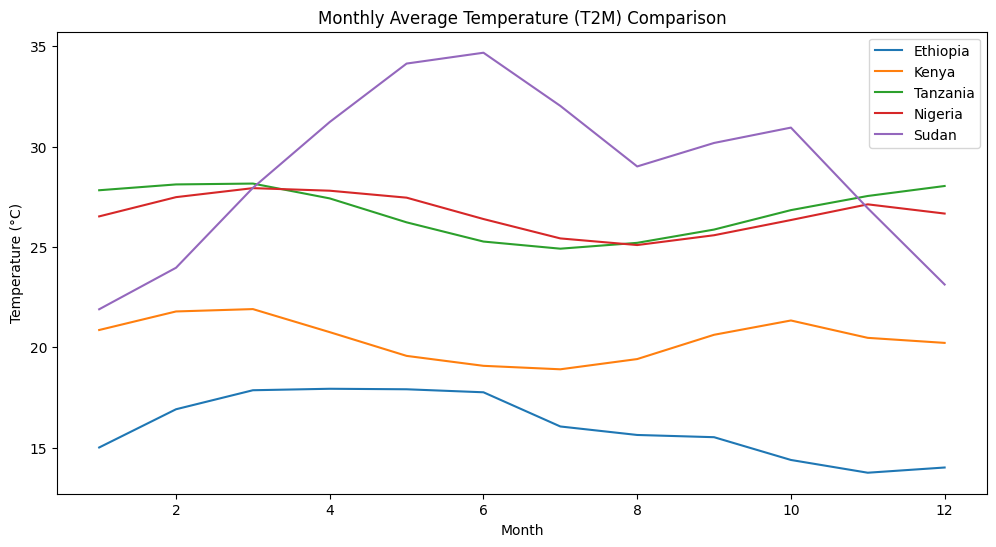

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in data["Country"].unique():
    subset = data[data["Country"] == country]
    monthly = subset.groupby("Month")["T2M"].mean()
    plt.plot(monthly.index, monthly.values, label=country)

plt.title("Monthly Average Temperature (T2M) Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

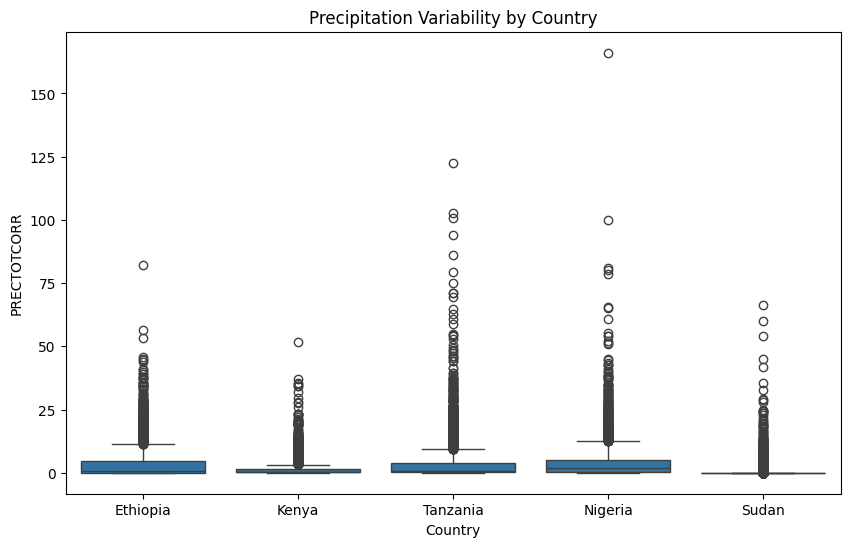

In [16]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=data)
plt.title("Precipitation Variability by Country")
plt.show()

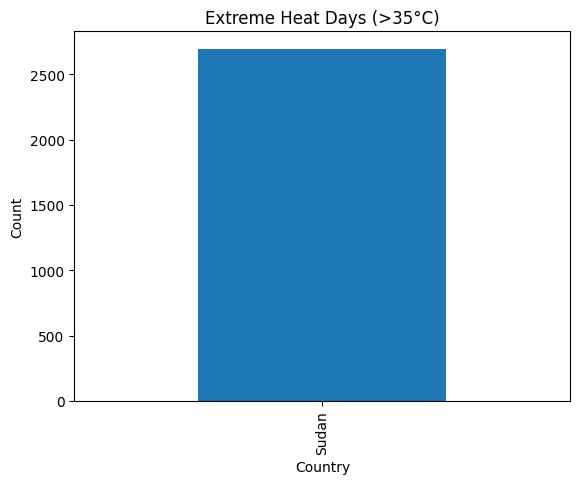

In [17]:
heat = data[data["T2M_MAX"] > 35]

heat_counts = heat.groupby("Country").size()

heat_counts.plot(kind="bar", title="Extreme Heat Days (>35°C)")
plt.ylabel("Count")
plt.show()

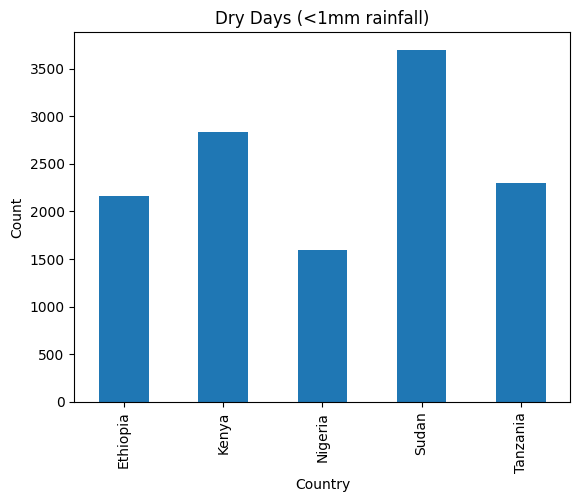

In [18]:
dry = data[data["PRECTOTCORR"] < 1]

dry_counts = dry.groupby("Country").size()

dry_counts.plot(kind="bar", title="Dry Days (<1mm rainfall)")
plt.ylabel("Count")
plt.show()

In [19]:
summary = data.groupby("Country").agg({
    "T2M": ["mean", "median", "std"],
    "PRECTOTCORR": ["mean", "median", "std"]
})

summary

T2M                  PRECTOTCORR                 
               mean median       std        mean median       std
Country                                                          
Ethiopia  16.068500  16.04  1.898050    3.633795   0.82  6.289061
Kenya     20.427600  20.36  1.440824    1.468162   0.38  3.180228
Nigeria   26.656928  26.82  1.123335    4.213914   1.84  7.266742
Sudan     28.759007  29.16  4.681305    0.643875   0.00  3.057672
Tanzania  26.802422  26.99  1.325388    3.740256   0.64  8.003947

In [20]:
import pandas as pd

summary = pd.DataFrame({
    "Country": ["Ethiopia","Kenya","Nigeria","Sudan","Tanzania"],
    "TempMean": [16.07, 20.43, 26.66, 28.76, 26.80],
    "RainMean": [3.63, 1.47, 4.21, 0.64, 3.74],
    "RainStd": [6.29, 3.18, 7.27, 3.06, 8.00]
})

summary

,Country,TempMean,RainMean,RainStd
0,Ethiopia,16.07,3.63,6.29
1,Kenya,20.43,1.47,3.18
2,Nigeria,26.66,4.21,7.27
3,Sudan,28.76,0.64,3.06
4,Tanzania,26.80,3.74,8.00


In [22]:
import pandas as pd

df = pd.DataFrame({
    "Country": ["Ethiopia","Kenya","Nigeria","Sudan","Tanzania"],
    "TempMean": [16.07, 20.43, 26.66, 28.76, 26.80],
    "RainMean": [3.63, 1.47, 4.21, 0.64, 3.74],
    "RainStd": [6.29, 3.18, 7.27, 3.06, 8.00]
})

In [23]:
df["TempRisk"] = df["TempMean"].rank()
df["DroughtRisk"] = df["RainMean"].rank(ascending=True)
df["InstabilityRisk"] = df["RainStd"].rank()

df["TotalRiskScore"] = (
    df["TempRisk"] +
    df["DroughtRisk"] +
    df["InstabilityRisk"]
)

df.sort_values("TotalRiskScore", ascending=False)

,Country,TempMean,RainMean,RainStd,TempRisk,DroughtRisk,InstabilityRisk,TotalRiskScore
4,Tanzania,26.80,3.74,8.00,4.0,4.0,5.0,13.0
2,Nigeria,26.66,4.21,7.27,3.0,5.0,4.0,12.0
0,Ethiopia,16.07,3.63,6.29,1.0,3.0,3.0,7.0
3,Sudan,28.76,0.64,3.06,5.0,1.0,1.0,7.0
1,Kenya,20.43,1.47,3.18,2.0,2.0,2.0,6.0
